In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D
from skimage import io, filters, img_as_ubyte, exposure
import pandas as pd
import re

# Define data and output directories
data_directory = os.path.join(r"L:\43-RVZ\AIMicroscopy\Mitarbeiter\2_Data\1_NikonTi2\FK_P001_EX004_2025_03_05 60x 1.5x KEIO Plate61 DIC Angle\TIF") # Set your data directory here
output_directory = os.path.join(data_directory, "results")  # Results folder inside data directory
os.makedirs(output_directory, exist_ok=True)

print("Current Directory:", os.getcwd())
print("Data Directory:", data_directory)
print("Output Directory:", output_directory)

Current Directory: C:\Users\fek64mu\Desktop\Projects\TIFocus
Data Directory: L:\43-RVZ\AIMicroscopy\Mitarbeiter\2_Data\1_NikonTi2\FK_P001_EX004_2025_03_05 60x 1.5x KEIO Plate61 DIC Angle\TIF
Output Directory: L:\43-RVZ\AIMicroscopy\Mitarbeiter\2_Data\1_NikonTi2\FK_P001_EX004_2025_03_05 60x 1.5x KEIO Plate61 DIC Angle\TIF\results


In [2]:
# Load the multi-frame TIFF (Z-Stack)
def load_tif_zstack(file_path):
    img_stack = io.imread(file_path)
    print(f"Loaded image stack with shape: {img_stack.shape}")  # (Z, Y, X) or (Z, Y, X, C) if multichannel
    return img_stack

In [3]:
# Compute Laplacian variance for each Z-slice
def compute_laplacian_variance(img_stack):
    variances = [np.var(filters.laplace(img_stack[z])) for z in range(img_stack.shape[0])]
    return variances

In [4]:
def create_intensity_profile(image_slice, line_width=3):
    # Define a vertical line around the center of the image
    y, x = image_slice.shape
    center_x = x // 2
    
    # Calculate the range of pixels to sample based on the line width
    start_x = max(center_x - line_width // 2, 0)
    end_x = min(center_x + line_width // 2 + 1, x)
    
    # Average the intensity over the line width
    intensity_profile = np.mean(image_slice[:, start_x:end_x], axis=1)  # Averaging over the specified width
    return intensity_profile

In [5]:
# Analyze stack and compute statistics
def analyze_stack(img_stack):
    stats = []
    for z in range(img_stack.shape[0]):
        slice_mean = np.mean(img_stack[z])
        slice_std = np.std(img_stack[z])
        stats.append({'Slice': z, 'Mean': slice_mean, 'Std': slice_std})
    return pd.DataFrame(stats)

In [6]:
# Normalize brightness to a visible range (0-255)
def normalize_brightness(image):
    # Rescale intensity to the full range (0 to 255)
    return exposure.rescale_intensity(image, in_range='image', out_range=(0, 255))

In [7]:
def show_highest_variance_slice(img_stack, variances, file_name):
    results_path = os.path.join(output_directory, f"{file_name}_analysis.png")
    csv_path = os.path.join(output_directory, f"{file_name}_analysis.csv")
    max_variance_index = np.argmax(variances)

    # Get the slice with the highest variance
    max_variance_slice = img_stack[max_variance_index]
    # Analyze stack
    stack_stats = analyze_stack(img_stack)
    stack_stats['Laplacian_Variance'] = variances
    # Save results to CSV
    stack_stats.to_csv(csv_path, index=False)
    # Normalize brightness (for visualization only)
    bright_slice = normalize_brightness(max_variance_slice)
    # Save the original sharpest slice as a TIF (without any modifications)
    sharpest_image_path = os.path.join(output_directory, f"{file_name}_sharpest_image.tif")
    io.imsave(sharpest_image_path, img_as_ubyte(max_variance_slice))  # Save the original slice as TIF
    # Create intensity profile
    intensity_profile = create_intensity_profile(max_variance_slice)
    # Crop the image for a closer look at the region of interest (around the center)
    y, x = max_variance_slice.shape
    crop_size = 500  # You can adjust this size based on your preference
    center_y, center_x = y // 2, x // 2
    crop_y_start = max(center_y - crop_size // 2, 0)
    crop_y_end = min(center_y + crop_size // 2, y)
    crop_x_start = max(center_x - crop_size // 2, 0)
    crop_x_end = min(center_x + crop_size // 2, x)
    cropped_slice = max_variance_slice[crop_y_start:crop_y_end, crop_x_start:crop_x_end]

    # Plot the results
    plt.figure(figsize=(18, 6))
    # Title for the entire figure
    plt.suptitle(f"Laplacian Variance Analysis Across Z-Slices\n({file_name})", fontsize=16, fontweight='bold', y=1.05)  # Adjusted title position

    # Plot Laplacian variance
    plt.subplot(1, 3, 1)
    plt.plot(range(len(variances)), variances, marker='o', linestyle='-', color='blue')
    plt.xlabel("Z-Slice Number", fontsize=12)
    plt.ylabel("Laplacian Variance", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xlim(0, len(variances))
    plt.title("Laplacian Variance Across Z-Slices", fontsize=14)

    # Plot image slice with intensity profile (using the brightened slice for visualization)
    plt.subplot(1, 3, 2)
    plt.imshow(bright_slice, cmap='gray')
    plt.title(f'Slice with Highest Variance Z-Slice {max_variance_index}', fontsize=14)
    plt.axis('off')

    # Plot cropped image (closer look)
    plt.subplot(1, 3, 3)
    plt.imshow(cropped_slice, cmap='gray')
    plt.title(f"Cropped Region Z-Slice {max_variance_index}", fontsize=14)
    plt.axis('off')

    # Create an additional plot for the intensity profile
    intensity_plot_path = os.path.join(output_directory, f"{file_name}_intensity_profile.png")
    
    fig_intensity, ax_intensity = plt.subplots(figsize=(12, 6))
    ax_intensity.plot(intensity_profile, label="Intensity Profile", color='red', linewidth=2)
    ax_intensity.set_title(f'Intensity Profile Z-Slice: {max_variance_index}', fontsize=16, fontweight='bold')
    ax_intensity.set_xlabel('Pixel Index (Y-direction)', fontsize=12)
    ax_intensity.set_ylabel('Intensity', fontsize=12)
    ax_intensity.legend(fontsize=12)
    ax_intensity.grid(True, linestyle='--', alpha=1.0)
    
    # Set x-axis limits based on image height
    ax_intensity.set_xlim(0, img_stack.shape[1])

    # Save the analysis plot with a unique name
    analysis_plot_path = os.path.join(output_directory, f"{file_name}_analysis.png")
    
    plt.tight_layout(pad=3.0)
    plt.subplots_adjust(top=0.85)  # Adjust top to create more space for the title
    
    output_path = os.path.join(output_directory, "laplacian_variance_3d_plot.png")
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print(f"The slice with the highest Laplacian variance is Z-Slice {max_variance_index}")
    print(f"Results saved to {csv_path}")
    print(f"Sharpened image saved to {sharpest_image_path}")


In [8]:
# Function to extract DIC angle from filename
def extract_dic_angle(filename):
    match = re.search(r"DIC([+-]?\d+)_", filename)
    if match:
        return int(match.group(1))  # Extracts +5 or -25 as integers
    return None  # Return None if no match found

In [9]:
def normalize_variance(variances):
    min_val, max_val = np.min(variances), np.max(variances)
    return (variances - min_val) / (max_val - min_val) if max_val > min_val else variances

In [10]:
def plot_laplacian_variance_3d(data_directory):
    fig = plt.figure(figsize=(16, 10))
    ax = fig.add_subplot(111, projection='3d')

    file_list = sorted([f for f in os.listdir(data_directory) if f.endswith(".tif") or f.endswith(".tiff")])

    dic_angles, all_variances, z_slices = [], [], None

    for filename in file_list:
        file_path = os.path.join(data_directory, filename)
        dic_angle = extract_dic_angle(filename)

        if dic_angle is not None:
            img_stack = io.imread(file_path)
            variances = compute_laplacian_variance(img_stack)
            dic_angles.append(dic_angle)
            all_variances.append(variances)

            if z_slices is None:
                z_slices = np.arange(len(variances))

    dic_angles = np.array(dic_angles)
    all_variances = np.array(all_variances)

    # Normalize all values globally
    global_max = np.max(all_variances)
    if global_max > 0:
        all_variances /= global_max

    sorted_indices = np.argsort(dic_angles)
    dic_angles = dic_angles[sorted_indices]
    all_variances = all_variances[sorted_indices]

    colormap = cm.coolwarm  # or cm.jet

    for i, (angle, variances) in enumerate(zip(dic_angles, all_variances)):
        colors = colormap(variances)  # Map each point to a color

        for j in range(len(z_slices) - 1):
            ax.plot(
                z_slices[j:j+2],
                [angle, angle],
                variances[j:j+2],
                color=colors[j],
                linewidth=2,
                alpha=1.0
            )

    ax.set_xlabel("Z-Slice Number", fontsize=14, labelpad=15)
    ax.set_ylabel("DIC Polarizer Angle (°)", fontsize=14, labelpad=15)
    ax.set_zlabel("Normalized Laplacian Variance", fontsize=14, labelpad=15)
    ax.set_title("Laplacian Variance Across Z-Slices for Different DIC Angles", fontsize=16, fontweight="bold")
    ax.set_ylim([-45, 45])

    plt.subplots_adjust(left=0.15, right=0.85, top=0.9, bottom=0.15)
    plt.show()

In [11]:
# Main analysis loop
def analyze_tif_stacks(data_directory, output_directory):
    for filename in os.listdir(data_directory):
        if filename.endswith(".tif") or filename.endswith(".tiff"):
            file_path = os.path.join(data_directory, filename)
            print(f"Analyzing: {filename}")
            img_stack = load_tif_zstack(file_path)
            variances = compute_laplacian_variance(img_stack)
            show_highest_variance_slice(img_stack, variances, file_name=os.path.splitext(filename)[0])

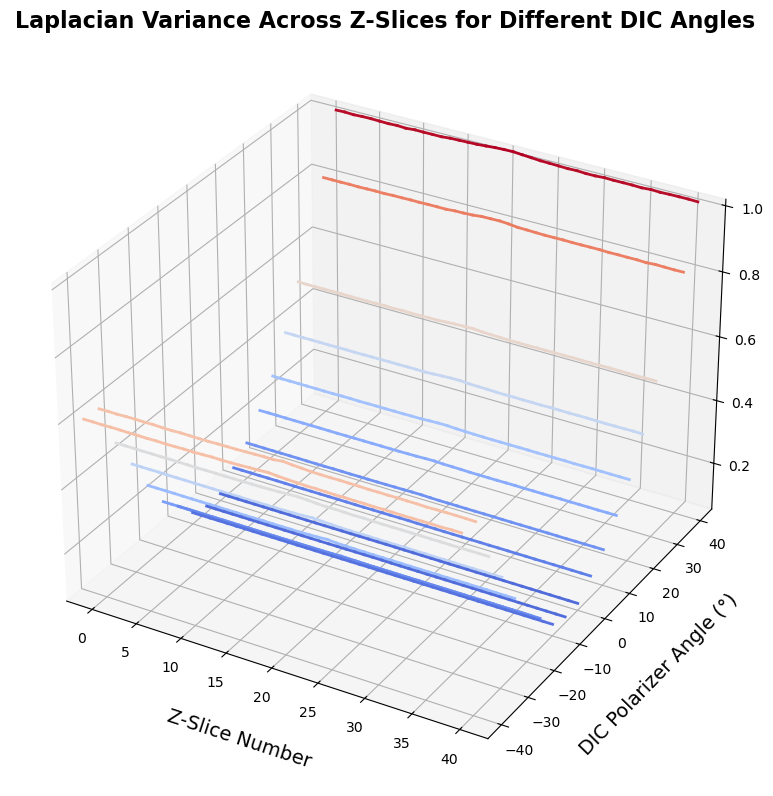

In [12]:
# Call the function with both parameters
plot_laplacian_variance_3d(data_directory)